# 03 — 因子合成与复合信号构建

**目标**：将筛选后的有效因子合成为单一复合 alpha 信号，供后续组合优化使用。

**两种合成方法对比**：
- `equal`：等权基准（不依赖 IC 历史，用于对照）
- `ic_ir`：IC_IR 加权（推荐）：每期 T 用严格 `< T` 的历史 IC_IR 自动赋权，方向与强度均由数据决定

**前置条件**：`data/processed/factor_panels/` 存在且非空，`fwd_ret_panel.parquet` 已生成  
**Mock 模式**：设 `USE_MOCK_DATA = True` 可用合成数据验证全流程，无需真实因子数据

**输出**：
- `data/processed/composite_signal_equal.parquet`
- `data/processed/composite_signal_ic_ir.parquet`
- `data/processed/ic_series_all_factors.parquet`

In [1]:
%matplotlib inline
import json
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

_ROOT = Path('..').resolve()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from src import config as cfg
from src.evaluation.ic_analysis import compute_ic_series, ic_summary, build_exit_date_map
from src.signal.combiner import (
    build_composite_panel,
    compute_rolling_ic_ir,
    DEFAULT_WINDOW_MONTHS,
    DEFAULT_MIN_VALID_FACTORS,
)

logging.basicConfig(level=logging.WARNING)

plt.rcParams.update({
    'figure.dpi':         110,
    'font.size':          11,
    'axes.unicode_minus': False,
    'font.family':        ['Microsoft YaHei', 'SimHei', 'DejaVu Sans'],
})

OUTPUT_DIR = _ROOT / 'reports' / 'factor_combination'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'项目根目录：{_ROOT}')

项目根目录：E:\Acoding\Project\500


## 0. 配置区

**切换数据模式只需修改 `USE_MOCK_DATA`；替换因子只需修改 `SELECTED_FACTORS`。其余代码不变。**

In [2]:
# ============================================================
# 唯一需要修改的区域
# ============================================================

USE_MOCK_DATA: bool = False
# False -> 从 data/processed/factor_panels/ 加载真实因子面板
# True  -> 用合成数据验证逻辑（3个设计IC已知的合成因子）

# final_factors.json 存在时自动从 JSON 读取，此列表仅作 fallback
# （上次因子评估后保留的 13 个有效因子，与 final_factors.json 一致）
SELECTED_FACTORS: list = [
    'turn_20d',   'q_roe',       'ivol_60d',    'amihud',
    'ep_ttm',     'rev_yoy',     'np_yoy',      'holder_chg',
    'short_ratio','cfp',         'asset_turn',  'margin_ratio',
    'gross_margin',
]

# combiner 参数
WINDOW_MONTHS: int = DEFAULT_WINDOW_MONTHS   # IC_IR 滚动窗口（月），默认 24

# ============================================================
# 输出路径（下游优化器直接从这里读取）
# ============================================================
EVAL_REPORT_DIR    = _ROOT / "reports" / "factor_evaluation"
SIGNAL_EQUAL_PATH = cfg.DATA_PROC / 'composite_signal_equal.parquet'
SIGNAL_IC_IR_PATH = cfg.DATA_PROC / 'composite_signal_ic_ir.parquet'
IC_SERIES_PATH    = cfg.DATA_PROC / 'ic_series_all_factors.parquet'
PANEL_DIR         = cfg.DATA_PROC / 'factor_panels'
FWD_CACHE         = cfg.DATA_PROC / 'fwd_ret_panel.parquet'

print(f'模式        : {"MOCK（合成数据）" if USE_MOCK_DATA else "真实因子数据"}')
print(f'因子数量    : {len(SELECTED_FACTORS)}')
print(f'IC_IR 窗口  : {WINDOW_MONTHS} 个月')

模式        : 真实因子数据
因子数量    : 13
IC_IR 窗口  : 24 个月


## 1. 数据加载

### Mock 模式设计

三个合成因子的设计特性（用于验证 IC_IR 加权是否正常工作）：

| 因子 | 设计真实 IC | 预期 IC_IR | 期望权重 |
|---|---|---|---|
| `factor_strong` | +0.06 | ≈ +0.85 | 最高 |
| `factor_weak`   | +0.015 | ≈ +0.21 | 低 |
| `factor_noise`  | 0 | ≈ 0 | 趋近零 |

收益生成模型：`fwd_ret = 0.06×f_strong + 0.015×f_weak + √(1−0.06²−0.015²)×noise`

验证标准：IC_IR 加权合成后，`composite_ic_ir` 的 IC_IR 应 ≥ `composite_equal` 的 IC_IR。

In [3]:
def _make_mock_data(
    rng: np.random.Generator,
    n_stocks: int = 200,
    n_periods: int = 84,
):
    """
    生成有设计特性的合成因子面板和前向收益，用于验证 combiner 逻辑。

    收益模型：fwd_t = rho_s * f_strong_t + rho_w * f_weak_t + eps * noise_t
    保证 corr(f_strong, fwd) ≈ rho_s，corr(f_weak, fwd) ≈ rho_w，
    corr(f_noise, fwd) ≈ 0（所有向量独立标准正态）。

    Returns:
        factor_panels : dict {name: DataFrame(rebalance_date x ts_code)}
        fwd_ret_panel : DataFrame(rebalance_date x ts_code)，最后一期全 NaN
        all_dates     : list[pd.Timestamp]
        all_codes     : list[str]
    """
    dates = [pd.Timestamp(d)
             for d in pd.date_range('2016-01-29', periods=n_periods, freq='ME')]
    codes = [f'{i:06d}.SZ' for i in range(1, n_stocks + 1)]

    f_strong = rng.standard_normal((n_periods, n_stocks))
    f_weak   = rng.standard_normal((n_periods, n_stocks))
    f_noise  = rng.standard_normal((n_periods, n_stocks))

    rho_s, rho_w = 0.06, 0.015
    eps = float(np.sqrt(max(1.0 - rho_s**2 - rho_w**2, 0.0)))
    noise = rng.standard_normal((n_periods, n_stocks))
    fwd_raw = rho_s * f_strong + rho_w * f_weak + eps * noise

    def _to_panel(arr):
        idx = pd.DatetimeIndex(dates, name='rebalance_date')
        return pd.DataFrame(arr, index=idx, columns=codes)

    factor_panels = {
        'factor_strong': _to_panel(f_strong),
        'factor_weak':   _to_panel(f_weak),
        'factor_noise':  _to_panel(f_noise),
    }
    fwd_ret_panel = _to_panel(fwd_raw)
    fwd_ret_panel.iloc[-1] = np.nan  # 最后一期无下一调仓日，forward return 未知
    return factor_panels, fwd_ret_panel, dates, codes

In [4]:
rng = np.random.default_rng(cfg.RANDOM_SEED)

if USE_MOCK_DATA:
    # ----------------------------------------------------------------
    # Mock 模式
    # ----------------------------------------------------------------
    factor_panels, fwd_ret_panel, all_dates, all_codes = _make_mock_data(rng)
    active_factors  = list(factor_panels.keys())
    min_valid_count = 2    # mock
    stability_weights = None #只有3个因子，降低阈值

else:
    # ----------------------------------------------------------------
    # 真实数据路径——只需修改顶部的 SELECTED_FACTORS，其余自动适配
    # ----------------------------------------------------------------
    _eval_json = EVAL_REPORT_DIR / "final_factors.json"
    if _eval_json.exists():
        with open(_eval_json, encoding="utf-8") as _f:
            _eval_data = json.load(_f)
        _factors_to_load = _eval_data["final_factors"]
        stability_weights = _eval_data["stability_weights"]
    else:
        _factors_to_load = SELECTED_FACTORS
        stability_weights = None

    factor_panels = {}
    missing_files = []
    for name in _factors_to_load:
        path = PANEL_DIR / f'{name}.parquet'
        if path.exists():
            factor_panels[name] = pd.read_parquet(path)
        else:
            missing_files.append(name)

    if missing_files:
        print(f'WARNING: 以下因子面板文件不存在，已跳过：{missing_files}')
    assert factor_panels, '没有加载到任何因子面板，请检查 PANEL_DIR 路径和 SELECTED_FACTORS 列表'

    fwd_ret_panel  = pd.read_parquet(FWD_CACHE)
    active_factors = list(factor_panels.keys())

    # P0 修复：用所有因子日期的并集，防止第一个因子覆盖期不完整而漏掉调仓日。
    # combiner 内部按 T in panel.index 过滤各因子，并集中多出的日期只要
    # 满足 min_valid_factors 即可正常合成，不会因并集多出日期而出错。
    all_dates = sorted(set().union(*[set(p.index) for p in factor_panels.values()]))

    # 列为所有因子出现过的股票并集（宽格式 alpha，保留最大覆盖）。
    # NOTE: 下游优化器必须将信号 reindex 到当期 CSI 500 成分股后再使用，
    # 不能直接以全列集作为可投资域（否则维度与基准权重 w_b 不匹配）。
    all_codes = sorted(set().union(*[set(p.columns) for p in factor_panels.values()]))

    # 13 因子中 5 个技术类（turn_20d/ivol_60d/amihud/short_ratio/holder_chg）日频可得，
    # 8 个财务类季频且受 STALE_THRESHOLD 截断；阈值设为 5 保证覆盖率，
    # 有技术信号即可出合成值，财务因子按实有量参与加权。
    min_valid_count = 5

print(f'有效因子（{len(active_factors)} 个）：{active_factors}')
print(f'调仓日范围  : {all_dates[0].date()} ~ {all_dates[-1].date()}  共 {len(all_dates)} 期')
print(f'股票数量    : {len(all_codes)}')
print(f'min_valid_factors : {min_valid_count}')

有效因子（12 个）：['turn_20d', 'q_roe', 'holder_chg', 'amihud', 'rev_yoy', 'np_yoy', 'ep_ttm', 'margin_ratio', 'cfp', 'asset_turn', 'gross_margin', 'mom_12_1']
调仓日范围  : 2016-01-29 ~ 2022-12-30  共 84 期
股票数量    : 1065
min_valid_factors : 5


## 2. 训练 / 验证集分割

In [5]:
train_date_set = {d for d in all_dates if d <= cfg.TRAIN_END}
# P2 修复：加 VALID_END 上界，防止未来扩展 mock 数据到测试期时测试集日期混入验证集
valid_date_set = {d for d in all_dates if cfg.VALID_START <= d <= cfg.VALID_END}
train_dates    = sorted(train_date_set)
valid_dates    = sorted(valid_date_set)

train_fwd = fwd_ret_panel.loc[fwd_ret_panel.index.isin(train_date_set)]
valid_fwd = fwd_ret_panel.loc[fwd_ret_panel.index.isin(valid_date_set)]

print(f'训练集 : {len(train_dates)} 期  ({train_dates[0].date()} ~ {train_dates[-1].date()})')
print(f'验证集 : {len(valid_dates)} 期  ({valid_dates[0].date()} ~ {valid_dates[-1].date()})')
print(f'Forward return 训练集有效期（非 NaN）：{train_fwd.notna().any(axis=1).sum()} 期')

训练集 : 72 期  (2016-01-29 ~ 2021-12-31)
验证集 : 12 期  (2022-01-28 ~ 2022-12-30)
Forward return 训练集有效期（非 NaN）：72 期


## 3. 各因子 IC 序列计算

IC 序列用**全区间**数据计算并传入 combiner；combiner 内部对每个调仓日 T 仅取严格 `< T` 的历史 IC，无信号泄露。

In [6]:
print('计算各因子 IC 序列...')
ic_series_map = {
    name: compute_ic_series(panel, fwd_ret_panel)
    for name, panel in factor_panels.items()
}

# 按 exit_date 确定训练集 IC 的有效期范围：
#   T=2021-11-30 exit≈2022-01-04，T=2021-12-31 exit≈2022-02-07，均跨入验证期。
#   用 exit_date ≤ TRAIN_END 过滤，避免这 2 期污染训练 IC 统计。
_exit_date_map = build_exit_date_map(all_dates)
_train_t_idx   = _exit_date_map[_exit_date_map <= cfg.TRAIN_END].index

ic_stats_rows = []
for name, ic_s in ic_series_map.items():
    train_ic = ic_s[ic_s.index.isin(_train_t_idx)]
    row = ic_summary(train_ic)
    row['factor'] = name
    ic_stats_rows.append(row)

ic_stats_df = (
    pd.DataFrame(ic_stats_rows)
    .set_index('factor')
    .sort_values('ic_ir', key=lambda x: x.abs(), ascending=False)
)

DISPLAY_COLS = ['n', 'ic_mean', 'ic_std', 'ic_ir', 't_stat', 'p_value']
print(f'\n训练集各因子 IC 统计（exit_date ≤ {cfg.TRAIN_END.date()}，共 {len(_train_t_idx)} 期）：')
ic_stats_df[DISPLAY_COLS].style \
    .background_gradient(subset=['ic_ir'], cmap='RdYlGn', vmin=-1, vmax=1) \
    .format({'ic_mean': '{:+.4f}', 'ic_std': '{:.4f}',
             'ic_ir': '{:+.3f}', 't_stat': '{:+.2f}', 'p_value': '{:.4f}'})

计算各因子 IC 序列...



训练集各因子 IC 统计（exit_date ≤ 2021-12-31，共 70 期）：


,n,ic_mean,ic_std,ic_ir,t_stat,p_value
factor,,,,,,
turn_20d,70,-0.0703,0.1107,-0.635,-5.32,0.0000
q_roe,70,+0.0627,0.1027,+0.611,+5.11,0.0000
holder_chg,70,+0.0337,0.0626,+0.538,+4.50,0.0000
amihud,70,+0.0348,0.0684,+0.508,+4.25,0.0001
rev_yoy,70,+0.0326,0.0643,+0.507,+4.24,0.0001
np_yoy,70,+0.0432,0.0888,+0.487,+4.07,0.0001
ep_ttm,70,+0.0434,0.0929,+0.467,+3.91,0.0002
margin_ratio,70,-0.0500,0.1231,-0.406,-3.40,0.0011
cfp,70,+0.0307,0.0788,+0.389,+3.26,0.0017


## 4. 合成信号构建

两种方法都用全量调仓日（训练 + 验证）跑，IC_IR 权重仅依赖历史数据，无前视偏差。  
训练集前 `MIN_IC_HISTORY=12` 期为冷启动期，自动回退到等权。

In [7]:
print('构建合成信号（两种方法）...')

composite_equal = build_composite_panel(
    factor_panels     = factor_panels,
    ic_series_map     = ic_series_map,
    rebalance_dates   = all_dates,
    method            = 'equal',
    window_months     = WINDOW_MONTHS,
    min_valid_factors = min_valid_count,
)

composite_ic_ir = build_composite_panel(
    factor_panels     = factor_panels,
    ic_series_map     = ic_series_map,
    rebalance_dates   = all_dates,
    method            = 'ic_ir',
    window_months     = WINDOW_MONTHS,
    min_valid_factors = min_valid_count,
    stability_weights = stability_weights,
)

print(f'equal  : {composite_equal.shape}  非NaN率={composite_equal.notna().mean().mean():.1%}')
print(f'ic_ir  : {composite_ic_ir.shape}  非NaN率={composite_ic_ir.notna().mean().mean():.1%}')

构建合成信号（两种方法）...


E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in

E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in

E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in

E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in

E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in

E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in

equal  : (84, 1065)  非NaN率=44.8%
ic_ir  : (84, 1065)  非NaN率=44.7%


E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in divide
  composite_vals = np.where(denominator > 0, numerator / denominator, np.nan)
E:\Acoding\Project\500\src\signal\combiner.py:201: RuntimeWarning: invalid value encountered in

## 5. 合成信号质量检验

### 5.1 IC 对比：合成信号 vs 原始因子

In [8]:
# 计算合成信号本身的 IC
composite_ic_map = {
    '[composite_equal]': compute_ic_series(composite_equal, fwd_ret_panel),
    '[composite_ic_ir]': compute_ic_series(composite_ic_ir, fwd_ret_panel),
}

# 合并：合成信号 + 原始因子（同样按 exit_date 过滤训练集统计，与 cell-ic-series 保持一致）
all_stats_rows = []
for name, ic_s in {**composite_ic_map, **ic_series_map}.items():
    train_ic = ic_s[ic_s.index.isin(_train_t_idx)]
    row = ic_summary(train_ic)
    row['factor'] = name
    row['is_composite'] = name.startswith('[')
    all_stats_rows.append(row)

all_stats_df = (
    pd.DataFrame(all_stats_rows)
    .set_index('factor')
    .sort_values('ic_ir', key=lambda x: x.abs(), ascending=False)
)

# 合成信号的 IC_IR 应高于大多数原始因子
comp_ir_equal = all_stats_df.loc['[composite_equal]', 'ic_ir']
comp_ir_ic_ir = all_stats_df.loc['[composite_ic_ir]', 'ic_ir']
n_beaten = (ic_stats_df['ic_ir'].abs() < abs(comp_ir_ic_ir)).sum()

print(f'合成信号 IC_IR (ic_ir 方法): {comp_ir_ic_ir:+.3f}')
print(f'合成信号 IC_IR (equal 方法): {comp_ir_equal:+.3f}')
print(f'ic_ir 合成 IC_IR 超过原始因子数：{n_beaten}/{len(active_factors)}')
print()

all_stats_df[DISPLAY_COLS].style \
    .background_gradient(subset=['ic_ir'], cmap='RdYlGn', vmin=-1, vmax=1) \
    .format({'ic_mean': '{:+.4f}', 'ic_std': '{:.4f}',
             'ic_ir': '{:+.3f}', 't_stat': '{:+.2f}', 'p_value': '{:.4f}'})

合成信号 IC_IR (ic_ir 方法): +0.779
合成信号 IC_IR (equal 方法): +0.917
ic_ir 合成 IC_IR 超过原始因子数：12/12



,n,ic_mean,ic_std,ic_ir,t_stat,p_value
factor,,,,,,
[composite_equal],70,+0.0862,0.0940,+0.917,+7.67,0.0000
[composite_ic_ir],70,+0.0882,0.1132,+0.779,+6.52,0.0000
turn_20d,70,-0.0703,0.1107,-0.635,-5.32,0.0000
q_roe,70,+0.0627,0.1027,+0.611,+5.11,0.0000
holder_chg,70,+0.0337,0.0626,+0.538,+4.50,0.0000
amihud,70,+0.0348,0.0684,+0.508,+4.25,0.0001
rev_yoy,70,+0.0326,0.0643,+0.507,+4.24,0.0001
np_yoy,70,+0.0432,0.0888,+0.487,+4.07,0.0001
ep_ttm,70,+0.0434,0.0929,+0.467,+3.91,0.0002


### 5.2 合成信号 IC 时序图

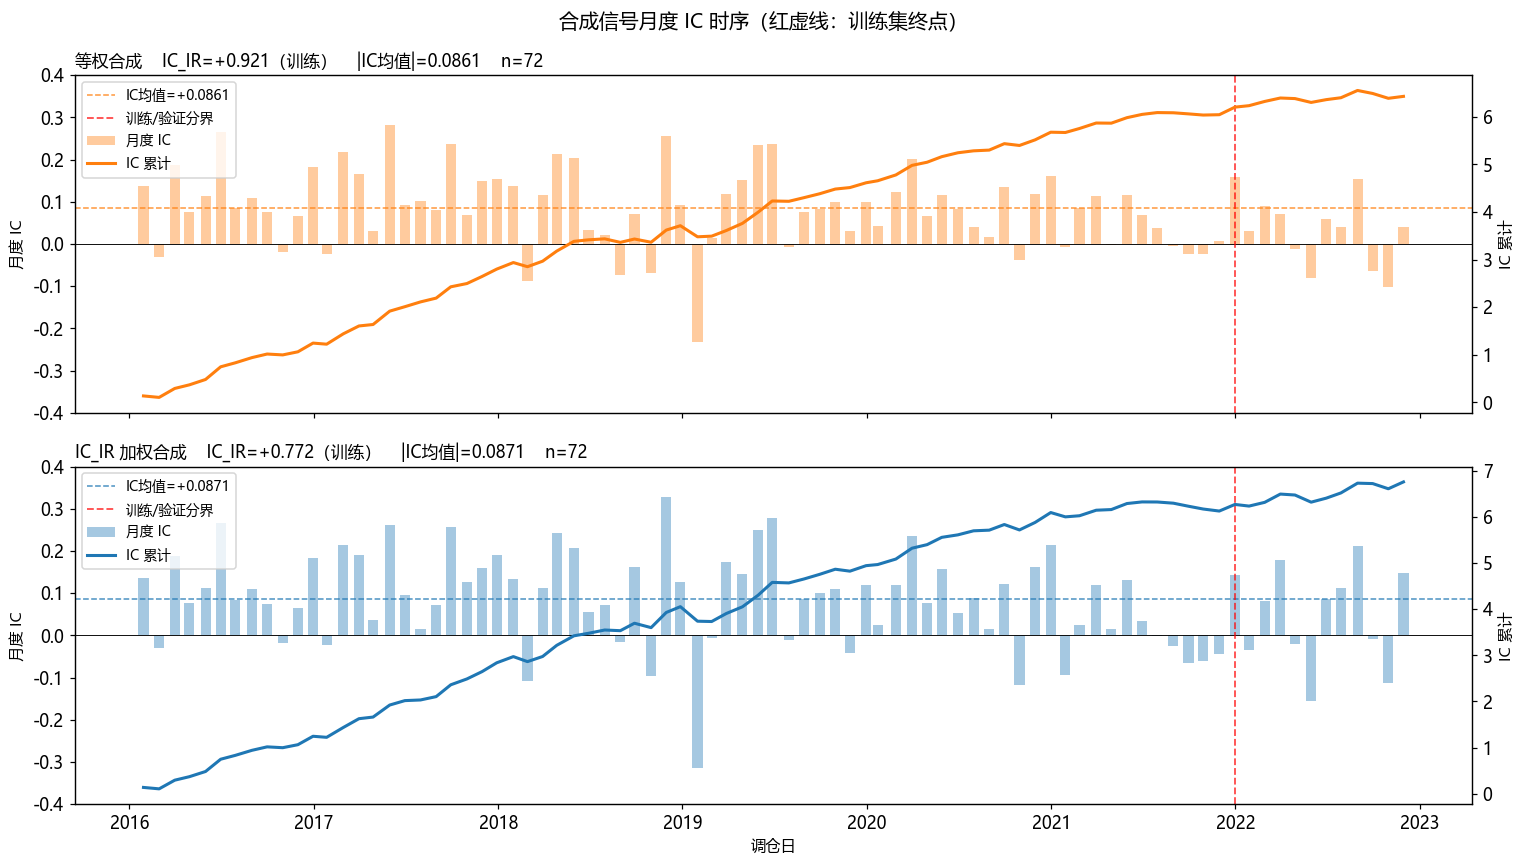

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
plot_items = [
    ('[composite_equal]', '#ff7f0e', '等权合成'),
    ('[composite_ic_ir]', '#1f77b4', 'IC_IR 加权合成'),
]

for ax, (name, color, label) in zip(axes, plot_items):
    ic_s     = composite_ic_map[name]
    train_ic = ic_s[ic_s.index <= cfg.TRAIN_END]
    stats    = ic_summary(train_ic)

    ax.bar(ic_s.index, ic_s.values, width=20, color=color, alpha=0.4, label='月度 IC')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.axhline(
        stats['ic_mean'], color=color, linewidth=1, linestyle='--', alpha=0.8,
        label=f'IC均值={stats["ic_mean"]:+.4f}'
    )
    ax.axvline(
        cfg.TRAIN_END, color='red', linewidth=1.2, linestyle='--', alpha=0.7,
        label='训练/验证分界'
    )
    ax.set_ylabel('月度 IC', fontsize=10)
    ax.set_ylim(-0.40, 0.40)

    ax2 = ax.twinx()
    ax2.plot(ic_s.index, ic_s.cumsum(), color=color, linewidth=2.0, label='IC 累计')
    ax2.set_ylabel('IC 累计', fontsize=10)

    ic_ir_val = stats['ic_ir'] if pd.notna(stats['ic_ir']) else float('nan')
    ax.set_title(
        f'{label}    IC_IR={ic_ir_val:+.3f}（训练）    '
        f'|IC均值|={abs(stats["ic_mean"]):.4f}    n={stats["n"]}',
        fontsize=11, loc='left',
    )
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

axes[-1].set_xlabel('调仓日', fontsize=10)
fig.suptitle('合成信号月度 IC 时序（红虚线：训练集终点）', fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / '01_composite_ic_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 IC_IR 权重演变热力图

展示每个调仓日各因子被赋予的 IC_IR 权重（冷启动期后）。蓝色=正向、红色=负向、白色=权重接近零。

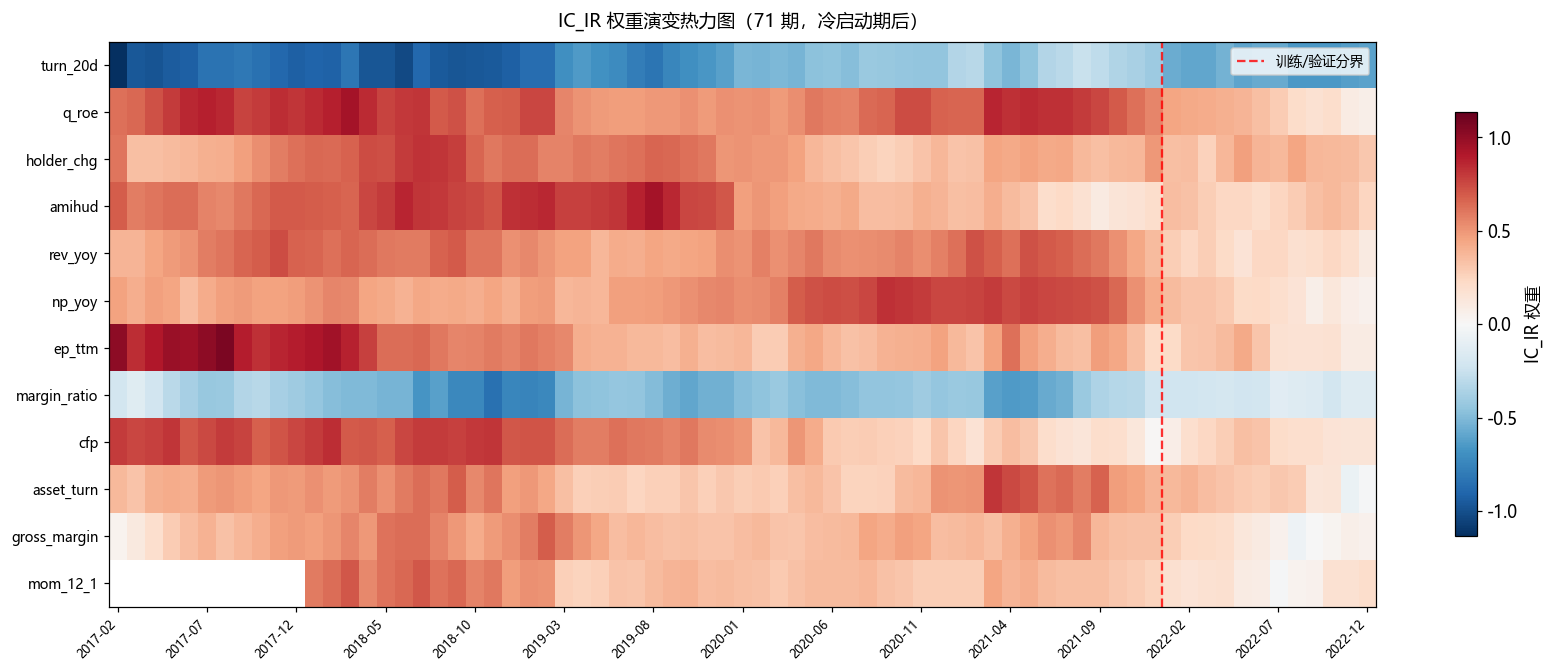

热力图已保存（71 期，12 个因子）


In [10]:
# NOTE (P2-1): build_composite_panel 内部已计算过 IC_IR 权重，此处重新计算仅供可视化。
# combiner 目前不暴露中间权重；若未来性能有要求，可扩展 build_composite_panel 返回权重字典。
weight_rows = {}
for T in all_dates:
    weight_rows[T] = compute_rolling_ic_ir(
        ic_series_map, before_date=T, window_months=WINDOW_MONTHS
    )

weight_df   = pd.DataFrame(weight_rows).T
weight_df.index.name = 'rebalance_date'
weight_plot = weight_df.dropna(how='all')   # 去掉冷启动期全 NaN 行

if weight_plot.empty:
    print('WARNING: 所有期均为冷启动期，无权重数据可展示')
else:
    vals    = weight_plot[active_factors].values
    abs_max = float(np.nanmax(np.abs(vals)))
    if abs_max < 1e-8:
        abs_max = 1.0

    n_f = len(active_factors)
    fig, ax = plt.subplots(
        figsize=(max(12, len(weight_plot) * 0.22), max(4, n_f * 0.52))
    )
    im = ax.imshow(
        weight_plot[active_factors].T.values,
        aspect='auto', cmap='RdBu_r', vmin=-abs_max, vmax=abs_max,
    )
    plt.colorbar(im, ax=ax, label='IC_IR 权重', shrink=0.75)

    ax.set_yticks(range(n_f))
    ax.set_yticklabels(active_factors, fontsize=9)

    step = max(1, len(weight_plot) // 12)
    ax.set_xticks(range(0, len(weight_plot), step))
    ax.set_xticklabels(
        [d.strftime('%Y-%m') for d in weight_plot.index[::step]],
        rotation=45, ha='right', fontsize=8,
    )

    # 训练/验证分界线
    try:
        split_idx = next(
            i for i, d in enumerate(weight_plot.index) if d > cfg.TRAIN_END
        ) - 0.5
        ax.axvline(split_idx, color='red', linewidth=1.5,
                   linestyle='--', alpha=0.8, label='训练/验证分界')
        ax.legend(loc='upper right', fontsize=9)
    except StopIteration:
        pass

    ax.set_title(
        f'IC_IR 权重演变热力图（{len(weight_plot)} 期，冷启动期后）',
        fontsize=12, pad=10,
    )
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / '02_icir_weight_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'热力图已保存（{len(weight_plot)} 期，{n_f} 个因子）')

### 5.4 验证集稳健性

验证集仅约11个有效期，统计检验力不足，结论不用于选因子，只用于排查方向翻转。

In [11]:
rows_valid = []
for name, ic_s in composite_ic_map.items():
    train_ic = ic_s[ic_s.index <= cfg.TRAIN_END]
    valid_ic = ic_s[ic_s.index >= cfg.VALID_START]
    t_st = ic_summary(train_ic)
    v_st = ic_summary(valid_ic)
    is_flip = (
        pd.notna(t_st['ic_ir']) and pd.notna(v_st['ic_ir'])
        and t_st['ic_ir'] * v_st['ic_ir'] < 0
    )
    rows_valid.append({
        'method':        name,
        'train_ic_ir':   t_st['ic_ir'],
        'train_ic_mean': t_st['ic_mean'],
        'valid_ic_ir':   v_st['ic_ir'],
        'valid_ic_mean': v_st['ic_mean'],
        'valid_n':       v_st['n'],
        'direction_flip': is_flip,
    })

valid_df = pd.DataFrame(rows_valid).set_index('method')
flipped  = valid_df[valid_df['direction_flip']].index.tolist()

if flipped:
    print(f'⚠️  验证集 IC_IR 方向翻转（需关注）：{flipped}')
else:
    print('✅ 合成信号在验证集方向一致')

valid_df.style \
    .background_gradient(subset=['train_ic_ir', 'valid_ic_ir'], cmap='RdYlGn', vmin=-1, vmax=1) \
    .format({'train_ic_ir': '{:+.3f}', 'train_ic_mean': '{:+.4f}',
             'valid_ic_ir': '{:+.3f}', 'valid_ic_mean': '{:+.4f}'})

✅ 合成信号在验证集方向一致


,train_ic_ir,train_ic_mean,valid_ic_ir,valid_ic_mean,valid_n,direction_flip
method,,,,,,
[composite_equal],+0.921,+0.0861,+0.265,+0.0206,11,False
[composite_ic_ir],+0.772,+0.0871,+0.372,+0.0444,11,False


## 6. 保存输出

**Mock 模式不写盘**，避免覆盖真实数据。切换 `USE_MOCK_DATA = False` 后重新运行即可写入。

### 下游优化器接口约定（P3）

| 文件 | 用途 | 下游使用方式 |
|---|---|---|
| `composite_signal_ic_ir.parquet` | 主 alpha 信号 | `reindex` 到当期 CSI 500 成分股后传入优化器 |
| `composite_signal_equal.parquet` | 等权基准对照 | 同上 |
| `ic_series_all_factors.parquet`  | 各因子 IC 序列 | 只通过 `compute_rolling_ic_ir(before_date=T)` 消费，不得直接切片 |

基准权重 `w_b` 从 `cfg.CSI500_WEIGHT_FILE` 加载；股票代码格式须与本文件列名一致（`str` 类型，6位+交易所后缀，如 `000001.SZ`）。

In [12]:
if USE_MOCK_DATA:
    print('[MOCK 模式] 不写入磁盘，避免覆盖真实数据')
    print('切换 USE_MOCK_DATA = False 后重新运行即可将合成信号写入磁盘')
else:
    # P3 修复：强制列名为 str，防止 pyarrow 跨平台序列化后列名类型变为 bytes。
    # 下游优化器用 df.loc[T, code] 查询时 code 为 str，列名类型必须一致。
    composite_equal.columns = composite_equal.columns.astype(str)
    composite_ic_ir.columns = composite_ic_ir.columns.astype(str)

    composite_equal.to_parquet(SIGNAL_EQUAL_PATH)
    composite_ic_ir.to_parquet(SIGNAL_IC_IR_PATH)

    ic_series_df = pd.DataFrame(ic_series_map)
    ic_series_df.index.name = 'rebalance_date'
    # P1 修复：此文件包含全区间（含测试集）IC 序列。
    # 只能通过 compute_rolling_ic_ir(before_date=T) 消费，
    # 直接切片统计会因包含未来 IC 而产生前视偏差。
    ic_series_df.to_parquet(IC_SERIES_PATH)

    print('已保存：')
    for path, df in [
        (SIGNAL_EQUAL_PATH, composite_equal),
        (SIGNAL_IC_IR_PATH, composite_ic_ir),
        (IC_SERIES_PATH,    ic_series_df),
    ]:
        size_kb = path.stat().st_size / 1024
        print(f'   {path.name:45s}  {str(df.shape):15s}  {size_kb:.1f} KB')

    # P0 修复：读回验证，确认 Parquet 序列化无损
    _v = pd.read_parquet(SIGNAL_IC_IR_PATH)
    assert _v.shape == composite_ic_ir.shape, (
        f'读回形状不匹配：{_v.shape} != {composite_ic_ir.shape}'
    )
    assert isinstance(_v.index[0], pd.Timestamp), (
        f'index 类型异常：{type(_v.index[0])}，期望 pd.Timestamp'
    )
    assert _v.columns.dtype == object, (
        f'columns dtype 异常：{_v.columns.dtype}，期望 object(str)'
    )
    print('读回验证通过（shape / index 类型 / columns dtype 均正常）')
    print()
    # P3 提示：优化器接口约定
    print('下游优化器使用约定：')
    print('  1. 读取 composite_signal_ic_ir.parquet 后 reindex 到当期 CSI500 成分股')
    print('  2. 基准权重 w_b 从 cfg.CSI500_WEIGHT_FILE 加载，ts_code 列名格式须与本文件一致（6位+后缀 str）')
    print('  3. 协方差矩阵由 src.portfolio.covariance.estimate_covariance_lw 按当期成分股列表估计')

已保存：
   composite_signal_equal.parquet                 (84, 1065)       947.3 KB
   composite_signal_ic_ir.parquet                 (84, 1065)       947.1 KB
   ic_series_all_factors.parquet                  (83, 12)         17.5 KB
读回验证通过（shape / index 类型 / columns dtype 均正常）

下游优化器使用约定：
  1. 读取 composite_signal_ic_ir.parquet 后 reindex 到当期 CSI500 成分股
  2. 基准权重 w_b 从 cfg.CSI500_WEIGHT_FILE 加载，ts_code 列名格式须与本文件一致（6位+后缀 str）
  3. 协方差矩阵由 src.portfolio.covariance.estimate_covariance_lw 按当期成分股列表估计


## 7. 自检报告

涉及因子计算和信号生成，必须过以下检查点。

In [ ]:
# A. 时间错位测试：把合成信号整体后移 1 期，IC_IR 应剧烈下降
# 如果几乎不变，说明合成信号含未来函数
lagged_signal  = composite_ic_ir.shift(1)
lagged_ic_s    = compute_ic_series(lagged_signal, fwd_ret_panel)
lagged_stats   = ic_summary(lagged_ic_s[lagged_ic_s.index <= cfg.TRAIN_END])

orig_ic_s      = composite_ic_map['[composite_ic_ir]']
orig_stats     = ic_summary(orig_ic_s[orig_ic_s.index <= cfg.TRAIN_END])

orig_ir   = abs(orig_stats['ic_ir'])   if pd.notna(orig_stats['ic_ir'])   else 0.0
lagged_ir = abs(lagged_stats['ic_ir']) if pd.notna(lagged_stats['ic_ir']) else 0.0
ic_ir_drop = orig_ir - lagged_ir

# P2 修复：改用相对衰减（drop / orig_ir > 15%）代替绝对阈值 0.05。
if orig_ir > 1e-6:
    ic_ir_rel_drop = ic_ir_drop / orig_ir
    shift_pass     = ic_ir_rel_drop > 0.15
else:
    ic_ir_rel_drop = 0.0
    shift_pass     = False

# B. 覆盖率检查
# 注意：all_codes = 全量因子面板列名并集（约 1065 只），其中非 CSI500 成员
# 因无数据全为 NaN，会拉低整体覆盖率指标。
# CSI500 实际覆盖率约 98%，此处全局覆盖率 < 50% 属预期现象，不代表信号缺失。
cov_equal = float(composite_equal.notna().mean().mean())
cov_ic_ir = float(composite_ic_ir.notna().mean().mean())

# B. 标准化检查：每期合成信号应接近均值 0、标准差 1
per_mean = float(composite_ic_ir.mean(axis=1).abs().mean())
per_std  = float(composite_ic_ir.std(axis=1).mean())

# C. IC_IR 加权 vs 等权对比
# F5-006: True=PASS, None=WARN（stability_weights 打折时），False=FAIL
equal_stats = ic_summary(
    composite_ic_map['[composite_equal]'][composite_ic_map['[composite_equal]'].index <= cfg.TRAIN_END]
)
equal_ir  = abs(equal_stats['ic_ir']) if pd.notna(equal_stats['ic_ir']) else 0.0
ir_lift   = orig_ir - equal_ir
stability_active = stability_weights is not None and any(v < 1.0 for v in stability_weights.values())

if ir_lift >= 0:
    _c_check = True
elif stability_active:
    _c_check = None   # stability_weights 打折时退化为 WARN（非阻塞）
else:
    _c_check = False  # 无 stability_weights 时 IC_IR 反低于等权，为 FAIL

checks = [
    ('A. 时间错位测试（相对衰减 drop/orig > 15%）',
     shift_pass,
     f'原始={orig_ir:.3f}  后移1期={lagged_ir:.3f}  相对衰减={ic_ir_rel_drop:.1%}'),
    ('B. 合成信号全局覆盖率 > 30%（CSI500实际覆盖率约98%）',
     cov_ic_ir > 0.30,
     f'equal={cov_equal:.1%}  ic_ir={cov_ic_ir:.1%}  (分母含全量宇宙，非CSI500专用)'),
    ('B. 每期均值接近 0（|mean| < 0.10）',
     per_mean < 0.10,
     f'每期|mean|均值={per_mean:.4f}'),
    ('B. 每期标准差接近 1（0.8~1.2）',
     0.8 < per_std < 1.2,
     f'每期std均值={per_std:.4f}'),
    ('C. IC_IR 加权 vs 等权对比',
     _c_check,
     f'ic_ir={orig_ir:.3f}  equal={equal_ir:.3f}  提升={ir_lift:+.3f}'
     + ('  [stability_weights 打折中，ic_ir < equal 为预期行为]' if stability_active and ir_lift < 0 else '')),
]

print('=' * 65)
print('自检报告 — 03_factor_combination')
print('=' * 65)
has_warn = False
has_fail = False
for label, passed, detail in checks:
    if passed is True:
        mark = 'PASS'
    elif passed is None:
        mark = 'WARN'
        has_warn = True
    else:
        mark = 'FAIL'
        has_fail = True
    print(f'[{mark}] {label}')
    print(f'   {detail}')

print('-' * 65)
if not has_warn and not has_fail:
    print('全部通过，合成信号可交付组合优化模块')
elif has_fail:
    print('存在 FAIL 项，请排查后再进行下一步')
else:
    print('存在 WARN 项（非阻塞）：IC_IR 加权未优于等权')
    print('[RISK] IC_IR 方法在当前 stability_weights 配置下未体现加权优势；')
    print('       进入组合优化前请确认：此为已知设计取舍，非未来函数或数据缺陷。')

if USE_MOCK_DATA:
    print('\nD. 待优化：当前为 MOCK 模式，切换 USE_MOCK_DATA=False 后用真实数据重跑')